# Customer Churn Analysis

## Data Cleaning

In this notebook, we will clean the Telco Customer Churn dataset before performing exploratory data analysis.

The objectives are:

- Import required libraries
- Load the dataset
- Inspect the dataset
- Check missing values
- Remove duplicates
- Correct data types
- Handle missing values
- Save the cleaned dataset

In [1]:
import pandas as pd
import numpy as np

## Import Dataset

Load the CSV file into a pandas DataFrame.

In [ ]:
df = pd.read_csv("D:\Customer_Churn_Analysis\Dataset\Telco-Customer-Churn.csv")

## Display First Five Rows

Understanding the structure of the dataset.

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Check Dataset Shape

Identify the number of rows and columns.

In [9]:
df.shape

(7043, 21)

## Dataset Information

Check column names, data types and missing values.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Check Missing Values

Identify columns containing null values.

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Check Duplicate Records

Determine whether duplicate rows exist.

In [13]:
df.duplicated().sum()

np.int64(0)

## Remove Duplicate Records

Delete duplicate rows if any are found.

In [15]:
df = df.drop_duplicates()

## Check Unique Values

Understand the categories present in each column.

In [16]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender
['Female' 'Male']
--------------------------------------------------
SeniorCitizen
[0 1]
--------------------------------------------------
Partner
['Yes' 'No']
--------------------------------------------------
Dependents
['No' 'Yes']
--------------------------------------------------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService
['No' 'Yes']
--------------------------------------------------
MultipleLines
['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSec

## Convert TotalCharges to Numeric

The 'TotalCharges' column is stored as an object because it contains blank spaces.
Convert it into numeric format.

In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

## Check Missing Values Again

After conversion, blank spaces become NaN values.

In [18]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Handle Missing Values

Replace missing values in TotalCharges using the median value.

In [20]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Save the Cleaned Dataset

Export the cleaned data for SQL and Power BI.

In [22]:
df.to_csv("Telco_Customer_Churn_Cleaned.csv", index=False)

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the data by identifying distributions, patterns, relationships, and trends before building dashboards or performing SQL analysis.

In [2]:
import matplotlib.pyplot as plt

## Churn Distribution

Analyze the proportion of customers who stayed and those who churned.

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv(r"D:\Customer_Churn_Analysis\Dataset\Telco-Customer-Churn.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

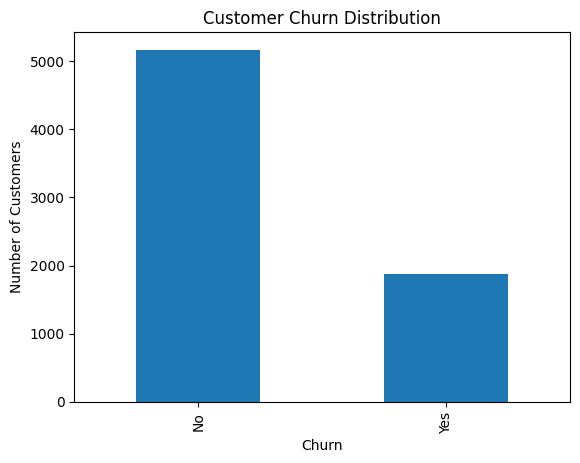

In [9]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Gender Distribution

Analyze the number of male and female customers.

In [10]:
df["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

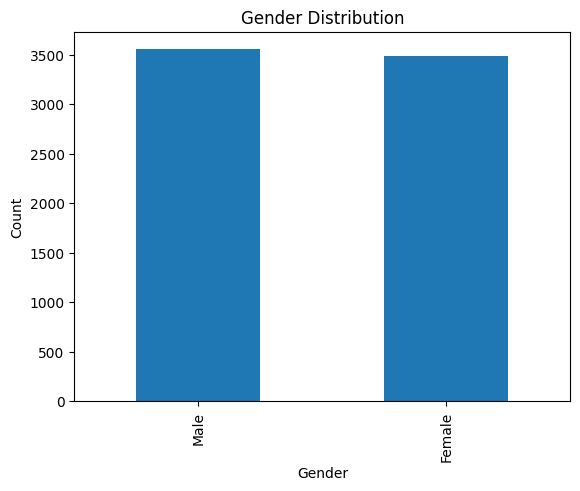

In [11]:
df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

## Contract Type Distribution

Understand which contract plans are preferred by customers.

In [12]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

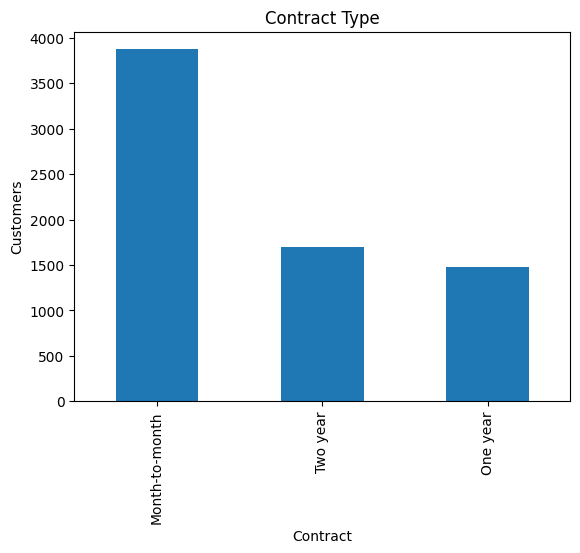

In [13]:
df["Contract"].value_counts().plot(kind="bar")

plt.title("Contract Type")
plt.xlabel("Contract")
plt.ylabel("Customers")

plt.show()

## Internet Service Distribution

Analyze the internet service used by customers.

In [14]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

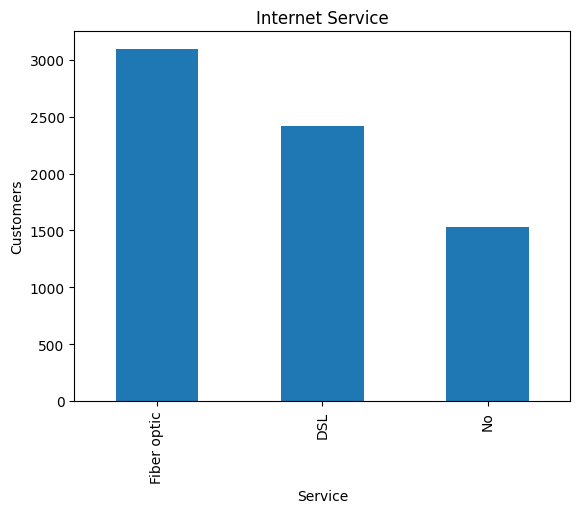

In [15]:
df["InternetService"].value_counts().plot(kind="bar")

plt.title("Internet Service")
plt.xlabel("Service")
plt.ylabel("Customers")

plt.show()

## Payment Method Distribution

Understand the most frequently used payment methods.

In [16]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customers")

plt.xticks(rotation=45)

plt.show()

## Monthly Charges Distribution

Visualize how monthly charges are distributed among customers.

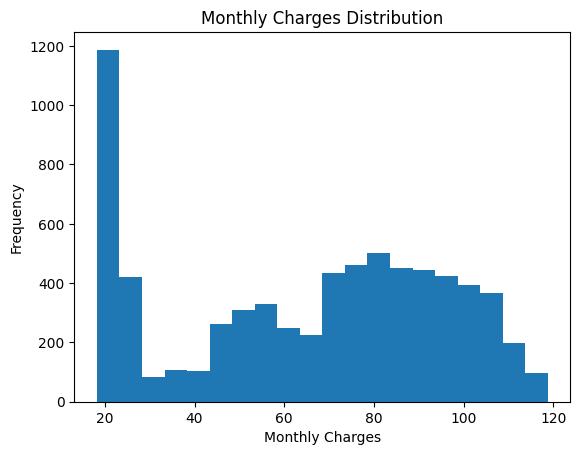

In [18]:
df["MonthlyCharges"].plot(kind="hist", bins=20)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

## Tenure Distribution

Analyze how long customers stay with the company.

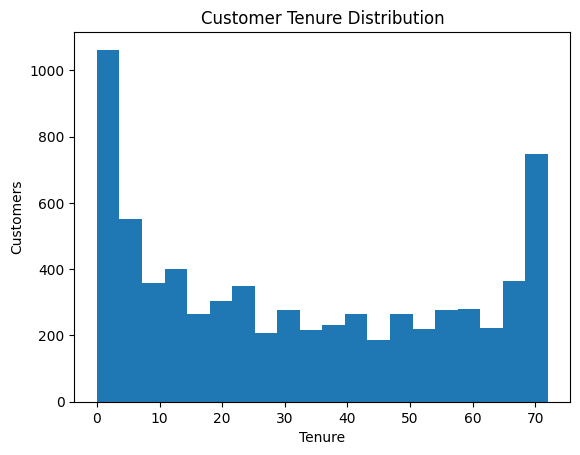

In [19]:
df["tenure"].plot(kind="hist", bins=20)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Customers")

plt.show()

## Total Charges Distribution

Analyze customer lifetime spending.

In [20]:
df["TotalCharges"].plot(kind="hist", bins=20)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Customers")

plt.show()

TypeError: no numeric data to plot

In [21]:
df["TotalCharges"].dtype


dtype('O')

In [22]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [23]:
df["TotalCharges"].isnull().sum()


np.int64(11)

In [24]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [25]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [26]:
df["TotalCharges"].dtype

dtype('float64')

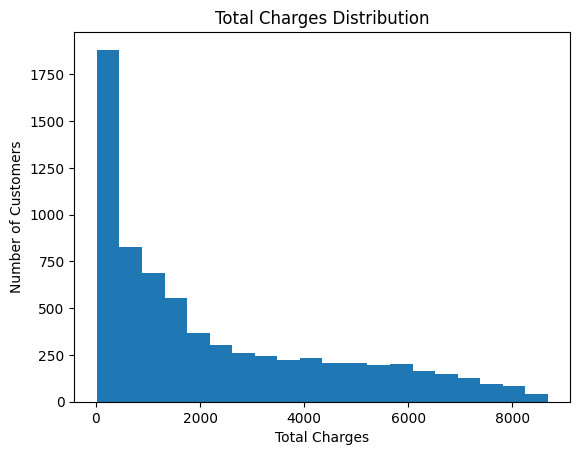

In [27]:
import matplotlib.pyplot as plt

df["TotalCharges"].plot(kind="hist", bins=20)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

# Bivariate Analysis

Bivariate analysis helps identify the relationship between customer churn and other variables such as gender, contract type, payment method, and internet service.

## Churn by Gender

Compare churn among male and female customers.

In [29]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


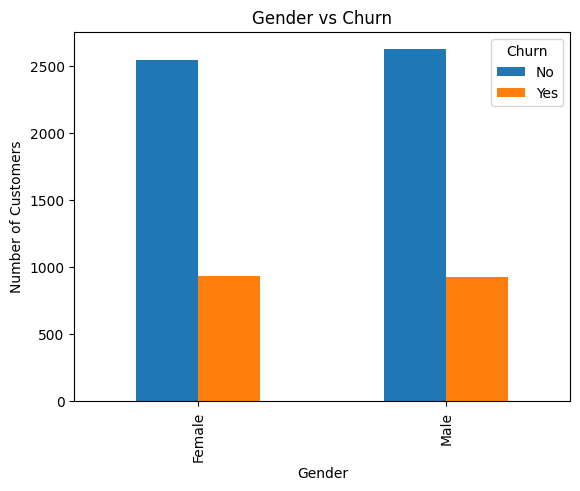

In [30]:
pd.crosstab(df["gender"], df["Churn"]).plot(kind="bar")

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## Churn by Senior Citizen

Analyze whether senior citizens are more likely to churn.

In [31]:
pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


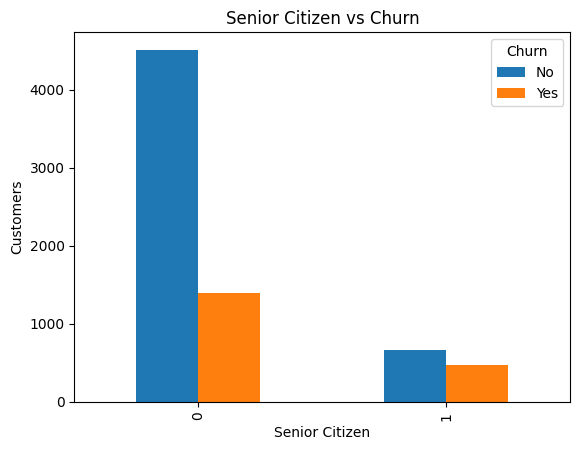

In [32]:
pd.crosstab(df["SeniorCitizen"], df["Churn"]).plot(kind="bar")

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Customers")

plt.show()

## Churn by Contract Type

Analyze the relationship between contract type and customer churn.

In [33]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


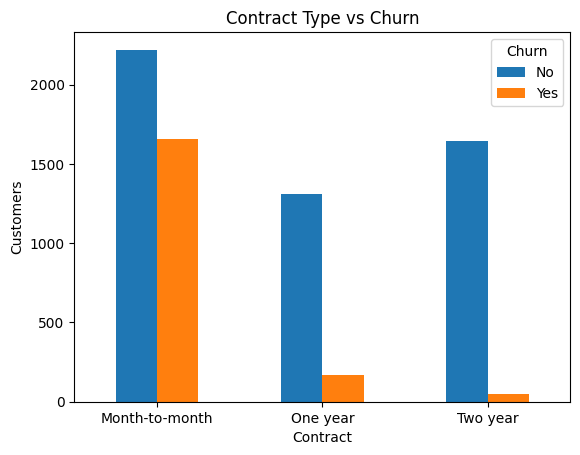

In [34]:

pd.crosstab(df["Contract"], df["Churn"]).plot(kind="bar")

plt.title("Contract Type vs Churn")
plt.xlabel("Contract")
plt.ylabel("Customers")

plt.xticks(rotation=0)

plt.show()

## Churn by Internet Service

Determine whether churn differs across internet service types.

In [35]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


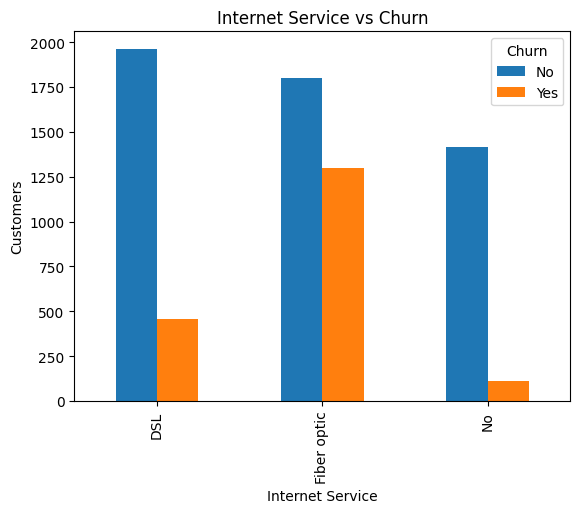

In [36]:
pd.crosstab(df["InternetService"], df["Churn"]).plot(kind="bar")

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Customers")

plt.show()

## Churn by Payment Method

Analyze churn based on customers' payment methods.

In [38]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


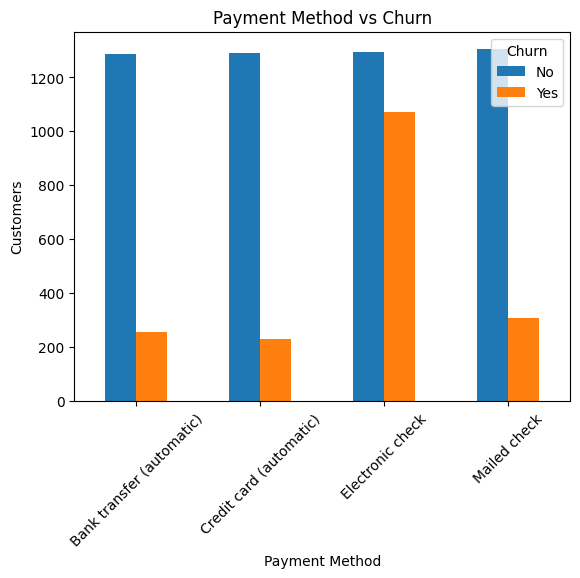

In [39]:
pd.crosstab(df["PaymentMethod"], df["Churn"]).plot(kind="bar")

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Customers")

plt.xticks(rotation=45)

plt.show()

## Monthly Charges by Churn

Compare monthly charges for churned and retained customers.

In [40]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


## Total Charges by Churn

Compare the total charges of churned and retained customers.

In [42]:
df.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2552.882494,2327.590132,18.80,579.575,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.500,703.550,2331.30,8684.80


## Tenure by Churn

Compare customer tenure between churned and retained customers.

In [43]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


## Correlation Analysis

Analyze the relationship between numerical variables.

In [44]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102652
tenure,0.016567,1.000000,0.247900,0.825464
MonthlyCharges,0.220173,0.247900,1.000000,0.650864
TotalCharges,0.102652,0.825464,0.650864,1.000000


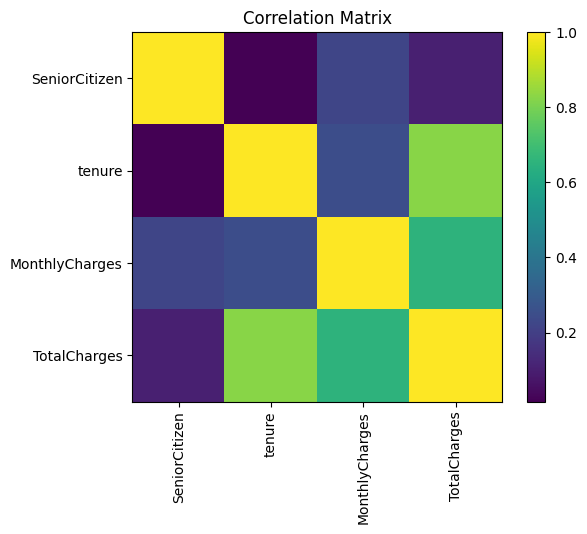

In [45]:
plt.imshow(numeric_df.corr())

plt.colorbar()

plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)

plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Matrix")

plt.show()

## Summary of EDA

Key observations from the exploratory data analysis:

- Customers with month-to-month contracts show higher churn.
- Customers with higher monthly charges tend to churn more.
- Long-tenure customers are less likely to churn.
- Fiber optic users have relatively higher churn.
- Electronic check users show higher churn rates.
- Senior citizens have a slightly higher churn rate than non-senior customers.